In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dense,LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [2]:
corpus=[
    "I love machine learning",
    'Sun rises in the East',
    'LSTM networks are used for sequence prediction'
    'Deep learning is Fascinating']

In [3]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(corpus)

In [4]:
total_words=len(tokenizer.word_index)+1
input_sequence=[]
for line in corpus:
    token_list=tokenizer.texts_to_sequences([line])[0]
    for i in range(1,len(token_list)):
        n_gram_sequence=token_list[:i+1]
        input_sequence.append(n_gram_sequence)

In [5]:
max_sequence_length=max(len(x) for x in input_sequence)
input_sequence=pad_sequences(input_sequence,max_sequence_length,padding='pre')
x,y=input_sequence[:,:-1],input_sequence[:,-1]
y=to_categorical(y,num_classes=total_words)

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
model=Sequential()
model.add(Embedding(total_words,100,input_length=max_sequence_length-1))
model.add(LSTM(150))
model.add(Dense(total_words,activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['Accuracy'])

In [8]:
history=model.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test))

Epoch 1/100


1/1 [==============================] - 10s 10s/step - loss: 2.9476 - Accuracy: 0.0000e+00 - val_loss: 2.9451 - val_Accuracy: 0.0000e+00
Epoch 2/100
1/1 [==============================] - 0s 91ms/step - loss: 2.9335 - Accuracy: 0.1667 - val_loss: 2.9548 - val_Accuracy: 0.0000e+00
Epoch 3/100
1/1 [==============================] - 0s 96ms/step - loss: 2.9194 - Accuracy: 0.3333 - val_loss: 2.9649 - val_Accuracy: 0.0000e+00
Epoch 4/100
1/1 [==============================] - 0s 103ms/step - loss: 2.9049 - Accuracy: 0.3333 - val_loss: 2.9760 - val_Accuracy: 0.0000e+00
Epoch 5/100
1/1 [==============================] - 0s 89ms/step - loss: 2.8892 - Accuracy: 0.4167 - val_loss: 2.9891 - val_Accuracy: 0.0000e+00
Epoch 6/100
1/1 [==============================] - 0s 61ms/step - loss: 2.8717 - Accuracy: 0.3333 - val_loss: 3.0051 - val_Accuracy: 0.0000e+00
Epoch 7/100
1/1 [==============================] - 0s 89ms/step - loss: 2.8515 - Accuracy: 0.2500 - val_loss: 3.0257 - val_Accura

In [9]:
import numpy as np
def pred_word_next(text):
    token_list=tokenizer.texts_to_sequences([text])[0]
    token_list=pad_sequences(
        [token_list],maxlen=max_sequence_length-1,padding='pre'
    )
    predict=model.predict(token_list)
    predicted=tokenizer.index_word[np.argmax(predict)]
    return predicted
new="I love machine"
print(pred_word_next(new))

1/1 [==============================] - 1s 1s/step
learning


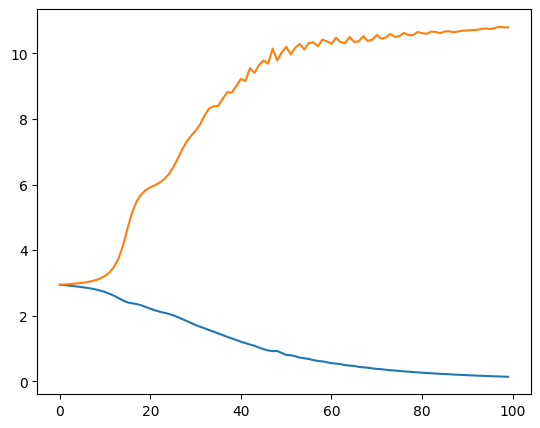

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
